# Exploratory Data Analysis

## Business Objective

The objective of this notebook is to explore the prepared sales dataset, identify important patterns, understand relationships between variables, and generate insights that guide feature engineering and model development.

## Workflow

- Load processed datasets
- Explore temporal sales patterns
- Analyze stores and product families
- Study sales distribution
- Evaluate promotions
- Investigate seasonality
- Examine external variables (oil prices and holidays)
- Analyze store characteristics and transactions
- Summarize key findings

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time series and statistics
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL


In [2]:
PROCESSED_DATA = Path("../data/processed")

train = pd.read_csv(PROCESSED_DATA / "train.csv", parse_dates=["date"])
oil = pd.read_csv(PROCESSED_DATA / "oil.csv", parse_dates=["date"])
transactions = pd.read_csv(PROCESSED_DATA / "transactions.csv", parse_dates=["date"])

stores = pd.read_csv("../data/raw/stores.csv")
holidays = pd.read_csv("../data/raw/holidays_events.csv", parse_dates=["date"])
test = pd.read_csv("../data/raw/test.csv", parse_dates=["date"])

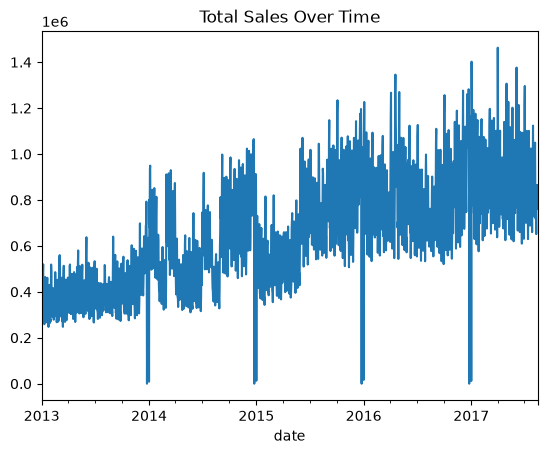

In [3]:
daily_sales = train.groupby("date")["sales"].sum()

plt.figure()
daily_sales.plot(title="Total Sales Over Time")
plt.show()

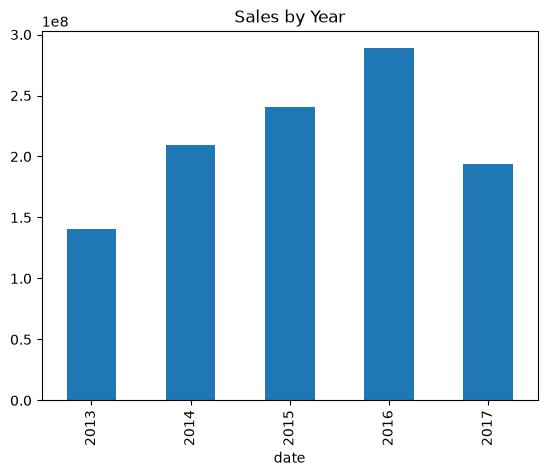

In [4]:
# Compare sales by year
train.groupby(train["date"].dt.year)["sales"].sum().plot(
    kind="bar", title="Sales by Year"
)
plt.show()

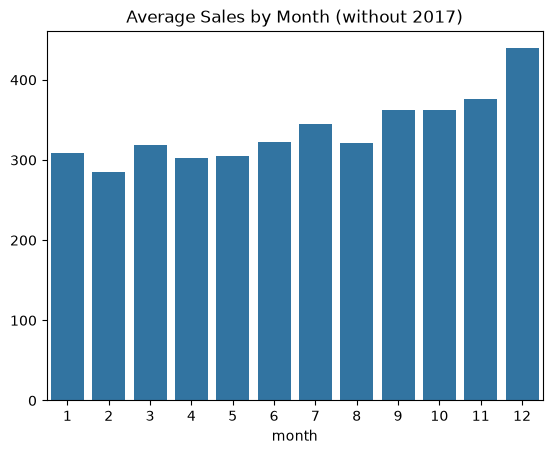

In [5]:
# Compare months without 2017 because 2017 is incomplete
train["month"] = train["date"].dt.month

month_sales = (
    train[train["date"].dt.year != 2017]
    .groupby("month")["sales"]
    .mean()
)

sns.barplot(x=month_sales.index, y=month_sales.values)
plt.title("Average Sales by Month (without 2017)")
plt.show()

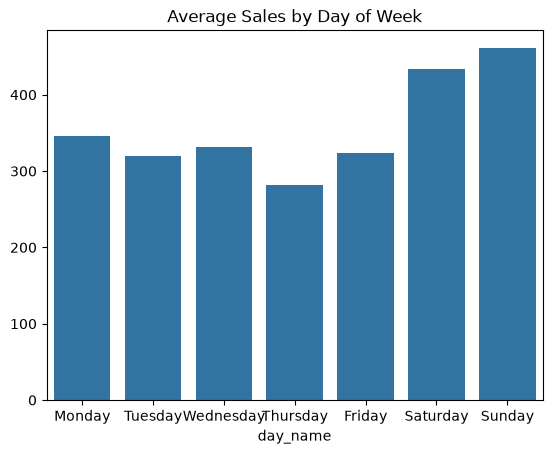

In [6]:
# Compare sales by day of week
train["day_name"] = train["date"].dt.day_name()

dow_sales = train.groupby("day_name")["sales"].mean()

# Fix the order of days of the week
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

sns.barplot(x=dow_sales.index, y=dow_sales.values, order=order)
plt.title("Average Sales by Day of Week")
plt.show()

In [7]:
train.head()

,date,store_nbr,family,id,sales,onpromotion,month,day_name
0,2013-01-01,1,AUTOMOTIVE,0.0,0.0,0.0,1,Tuesday
1,2013-01-01,1,BABY CARE,1.0,0.0,0.0,1,Tuesday
2,2013-01-01,1,BEAUTY,2.0,0.0,0.0,1,Tuesday
3,2013-01-01,1,BEVERAGES,3.0,0.0,0.0,1,Tuesday
4,2013-01-01,1,BOOKS,4.0,0.0,0.0,1,Tuesday


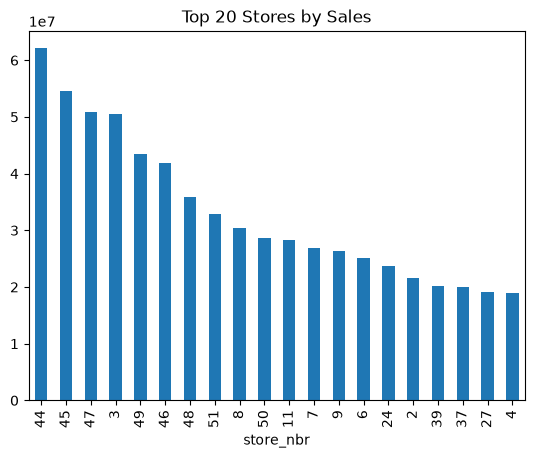

In [8]:
# Calculate total sales by store
store_sales = train.groupby("store_nbr")["sales"].sum().sort_values(ascending=False)

store_sales.head(20).plot(kind="bar", title="Top 20 Stores by Sales")
plt.show()

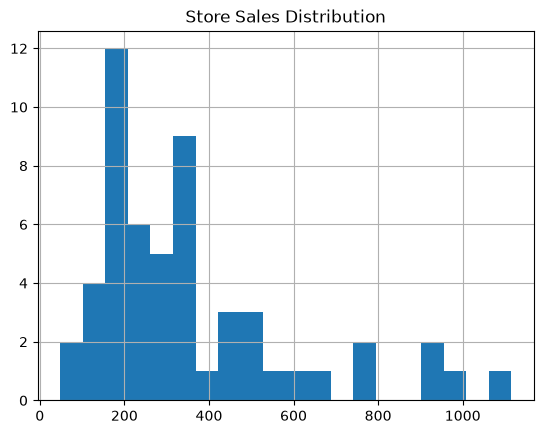

In [9]:
# Calculate average daily sales by store
train.groupby("store_nbr")["sales"].mean().hist(bins=20)
plt.title("Store Sales Distribution")
plt.show()

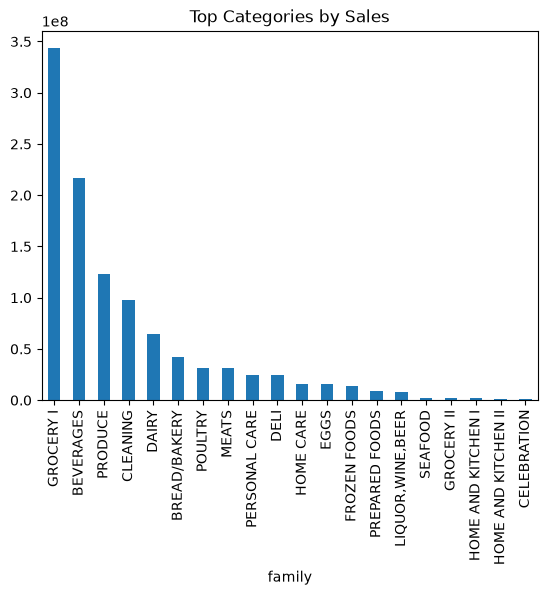

In [10]:
# Compare sales by product category
family_sales = train.groupby("family")["sales"].sum().sort_values(ascending=False)

family_sales.head(20).plot(kind="bar", title="Top Categories by Sales")
plt.show()

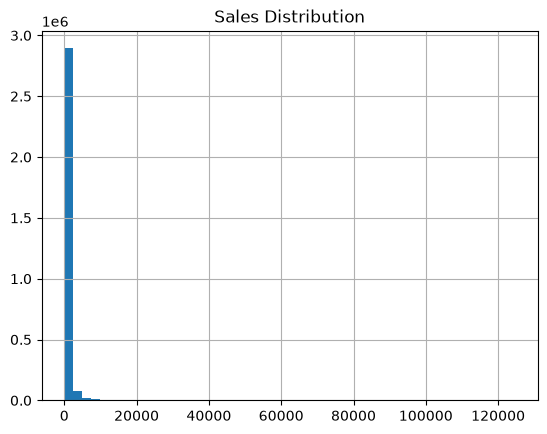

In [11]:
# Look at the distribution of the target variable
train["sales"].hist(bins=50)
plt.title("Sales Distribution")
plt.show()

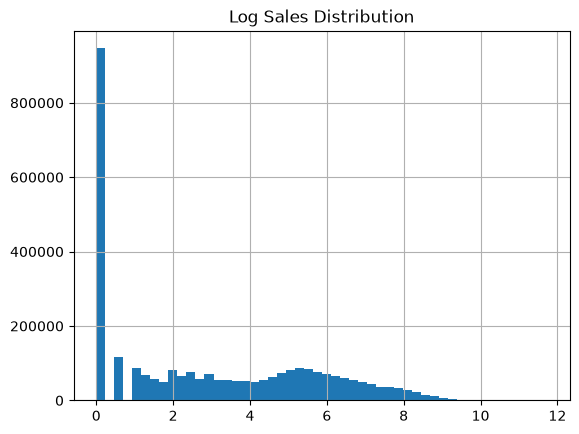

In [12]:
# Look at the distribution of the target variable (log scale for better visualization)
np.log1p(train["sales"]).hist(bins=50)
plt.title("Log Sales Distribution")
plt.show()

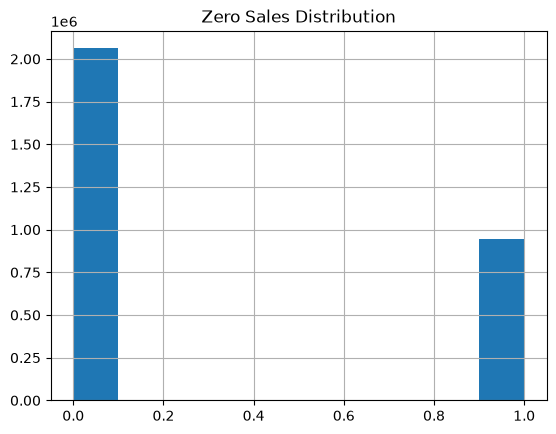

In [13]:
train["sales"].eq(0).astype(int).hist()
plt.title("Zero Sales Distribution")
plt.show()

In [14]:
# Calculate the share of zero sales by category
zero_by_family = train.groupby("family")["sales"].apply(lambda x: (x == 0).mean())

# Show categories with the highest zero share
zero_by_family.sort_values(ascending=False).head(10)

family
BOOKS                         0.969622
BABY CARE                     0.941449
SCHOOL AND OFFICE SUPPLIES    0.741443
HOME APPLIANCES               0.735804
LADIESWEAR                    0.599416
MAGAZINES                     0.566417
PET SUPPLIES                  0.547229
HARDWARE                      0.479858
LAWN AND GARDEN               0.469107
PLAYERS AND ELECTRONICS       0.450171
Name: sales, dtype: float64

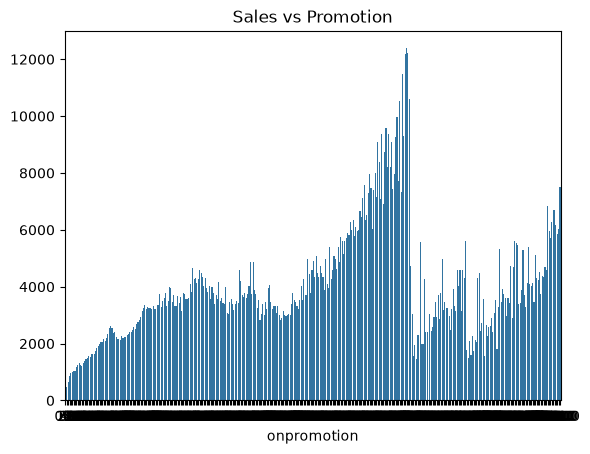

In [15]:
# Calculate average sales depending on promotion
promo_sales = train.groupby("onpromotion")["sales"].mean()

# Visualize the relationship between promotions and sales
sns.barplot(x=promo_sales.index, y=promo_sales.values)
plt.title("Sales vs Promotion")
plt.show()

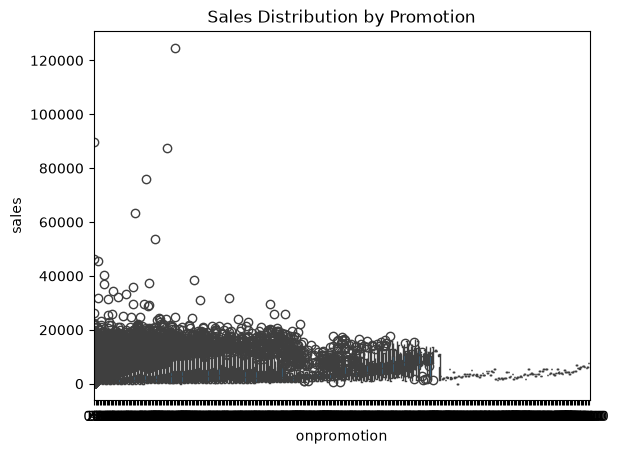

In [16]:
# Compare sales distribution by different promotion counts
sns.boxplot(x=train["onpromotion"], y=train["sales"])
plt.title("Sales Distribution by Promotion")
plt.show()

In [17]:
# Calculate correlation between sales and promotions
train[["sales", "onpromotion"]].corr()

,sales,onpromotion
sales,1.000000,0.428011
onpromotion,0.428011,1.000000


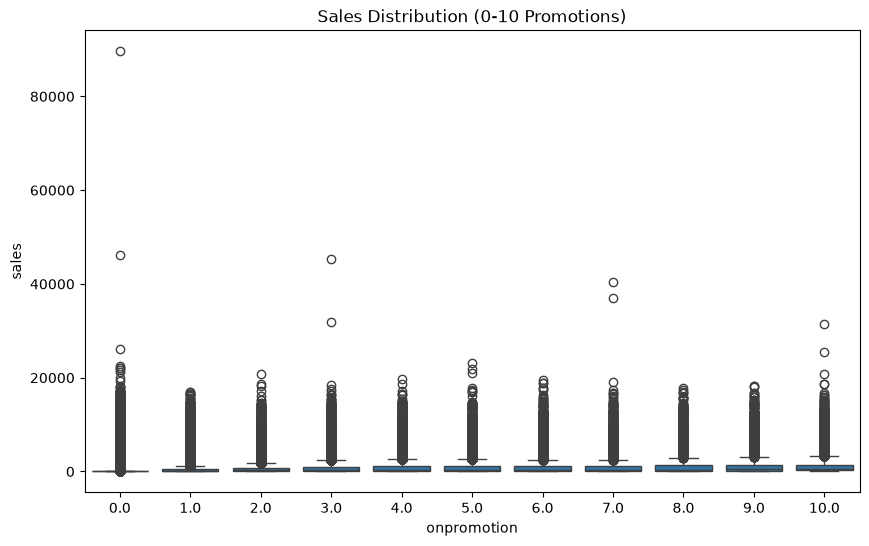

In [18]:
subset = train[train["onpromotion"] <= 10]

plt.figure(figsize=(10,6))
sns.boxplot(data=subset, x="onpromotion", y="sales")
plt.title("Sales Distribution (0-10 Promotions)")
plt.show()

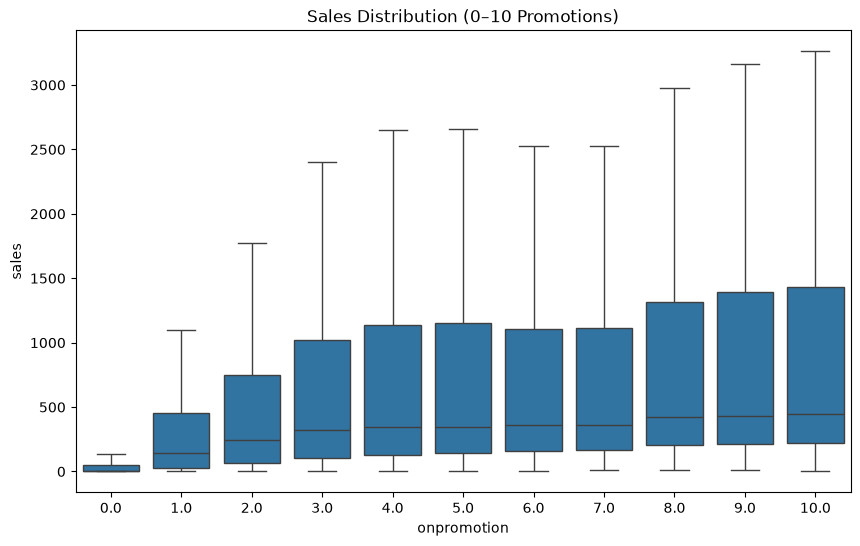

In [19]:
subset = train[train["onpromotion"] <= 10]

plt.figure(figsize=(10,6))
sns.boxplot(
    data=subset,
    x="onpromotion",
    y="sales",
    showfliers=False
)
plt.title("Sales Distribution (0–10 Promotions)")
plt.show()

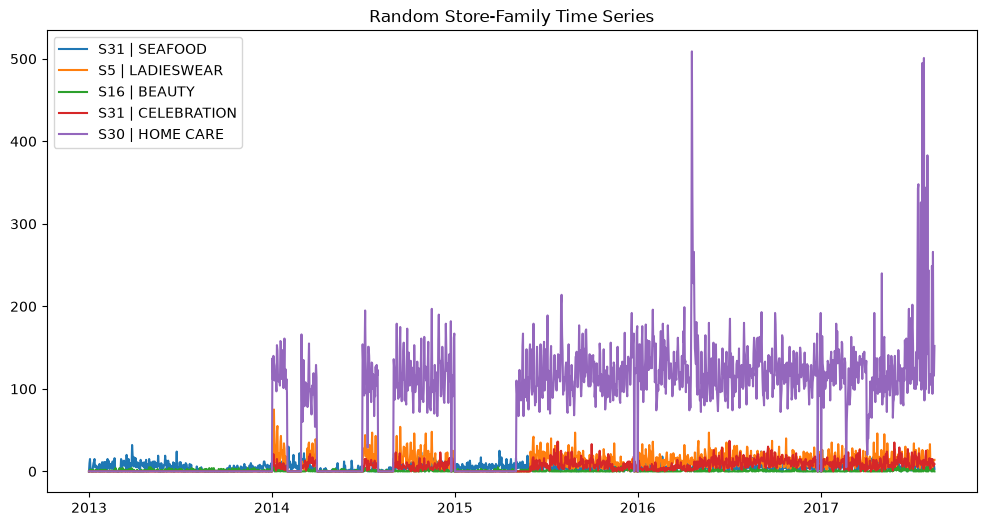

In [20]:
# Look at individual store × category time series
plt.figure(figsize=(12,6))

samples = train[["store_nbr", "family"]].drop_duplicates().sample(5, random_state=42)

for _, row in samples.iterrows():
    sample = train[
        (train["store_nbr"] == row["store_nbr"]) &
        (train["family"] == row["family"])
    ]

    ts = sample.groupby("date")["sales"].sum()
    plt.plot(ts, label=f"S{row['store_nbr']} | {row['family']}")

plt.legend()
plt.title("Random Store-Family Time Series")
plt.show()

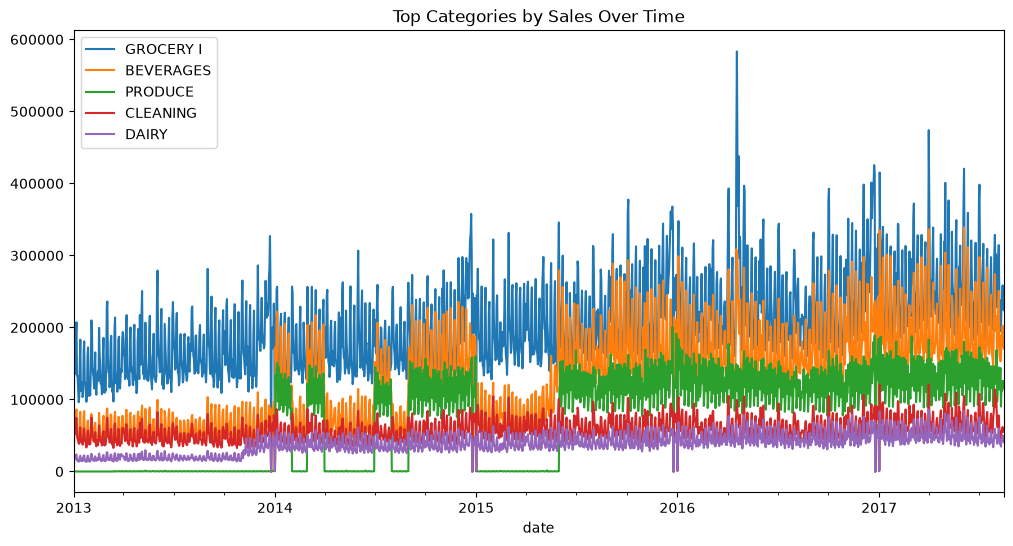

In [21]:
# Show top 5 categories by total sales
top_families = (
    train.groupby("family")["sales"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

plt.figure(figsize=(12,6))

for fam in top_families:
    sample = train[train["family"] == fam]
    sample.groupby("date")["sales"].sum().plot(label=fam)

plt.legend()
plt.title("Top Categories by Sales Over Time")
plt.show()

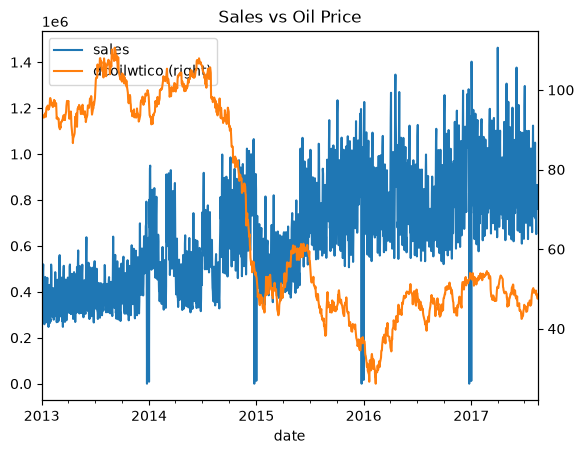

In [22]:
# Compare sales and oil price
merged = (
    train.groupby("date")["sales"]
    .sum()
    .reset_index()
    .merge(oil, on="date", how="left")
)

merged.plot(x="date", y=["sales", "dcoilwtico"], secondary_y="dcoilwtico")
plt.title("Sales vs Oil Price")
plt.show()

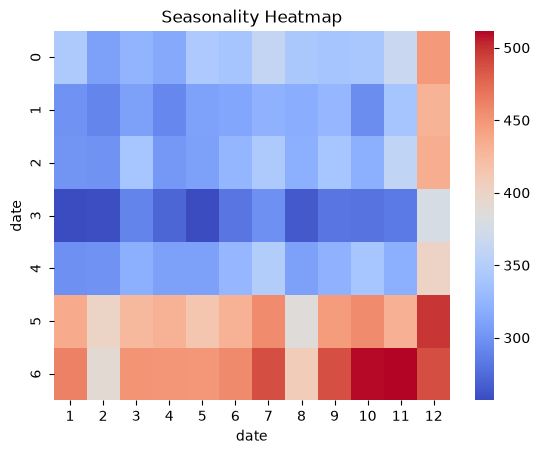

In [23]:
# Build a seasonality heatmap by day of week and month

pivot = train.groupby([
    train["date"].dt.dayofweek,
    train["date"].dt.month
])["sales"].mean().unstack()

sns.heatmap(pivot, cmap="coolwarm")
plt.title("Seasonality Heatmap")
plt.show()

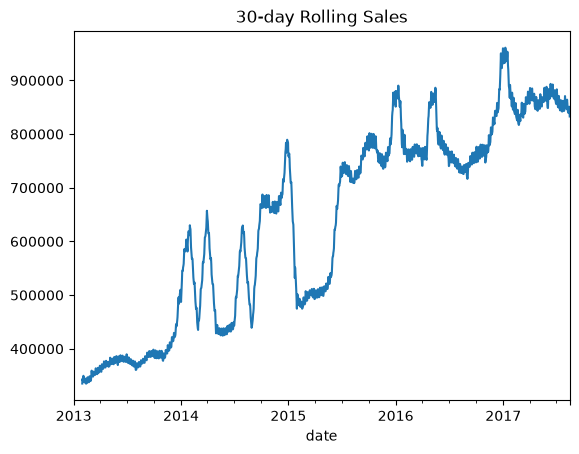

In [24]:
 # Add 30-day rolling mean to the sales trend
train.groupby("date")["sales"].sum().rolling(30).mean().plot()
plt.title("30-day Rolling Sales")
plt.show()

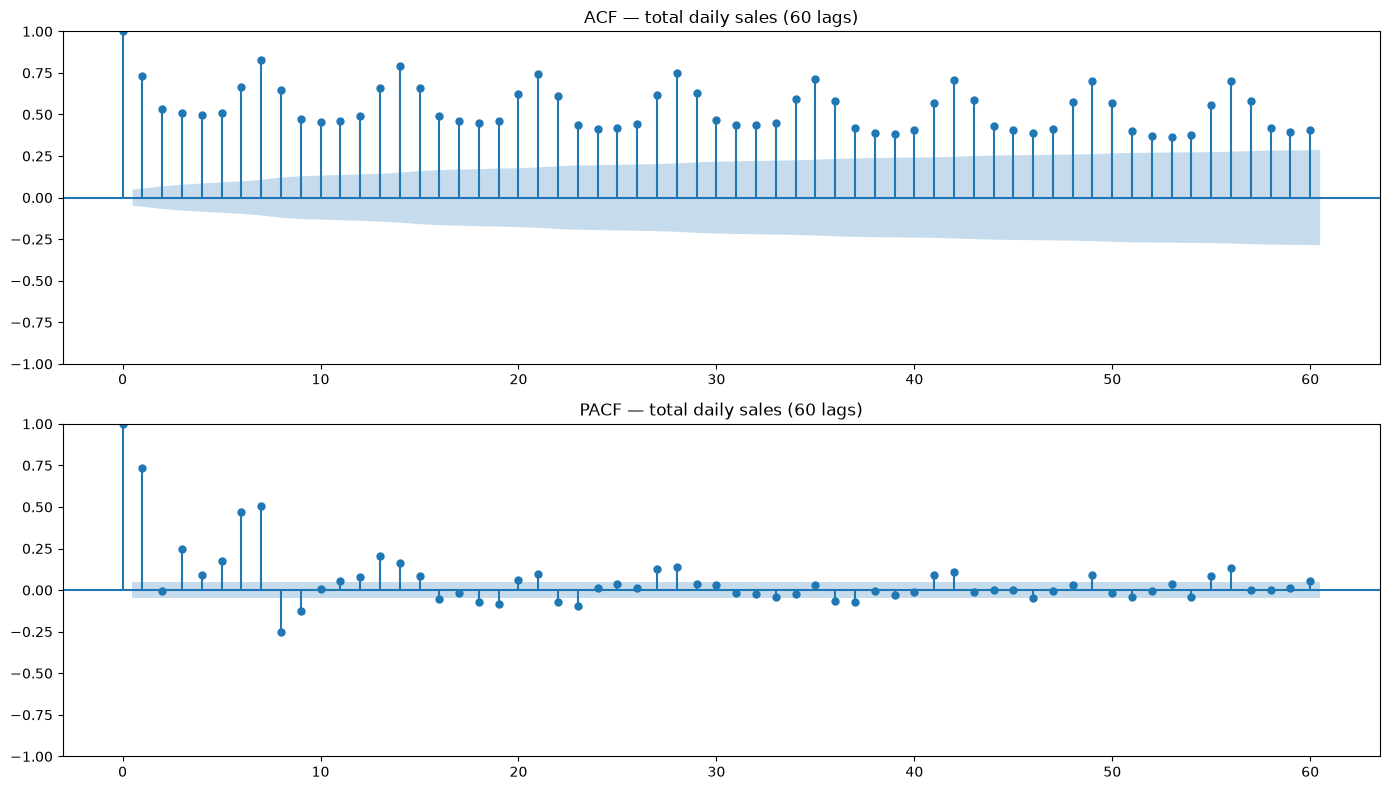

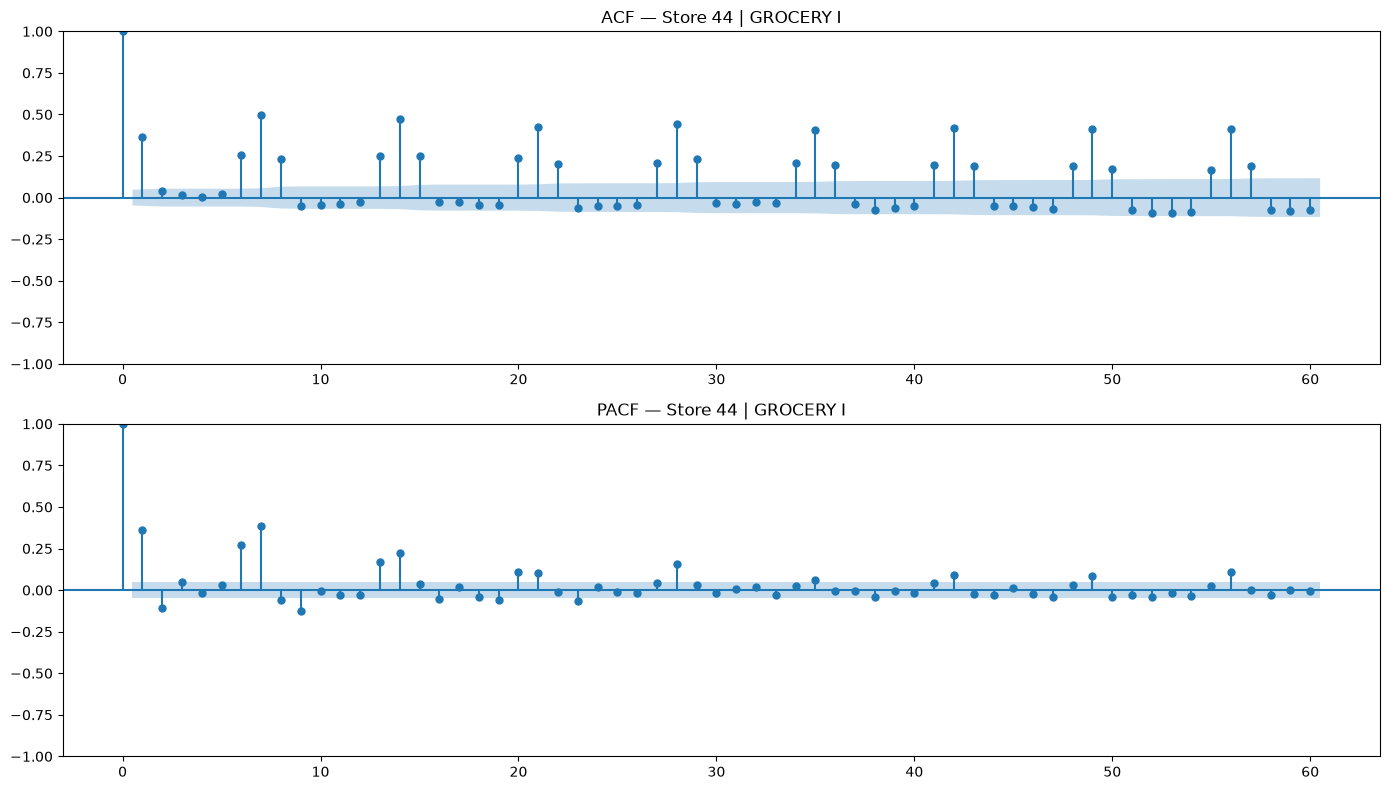

Significant ACF lags (up to 30):  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
Significant PACF lags (up to 30): [1, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 18, 19, 20, 21, 22, 23, 27, 28]

Significance threshold: ±0.0487


In [25]:
# Aggregate sales to a daily series
daily_sales = train.groupby("date")["sales"].sum().sort_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(daily_sales, lags=60, ax=axes[0], title="ACF — total daily sales (60 lags)")
plot_pacf(daily_sales, lags=60, ax=axes[1], title="PACF — total daily sales (60 lags)", method="ywm")

plt.tight_layout()
plt.show()

# Additionally inspect ACF/PACF for one large series
# Take the largest store and the top-selling category
top_store = train.groupby("store_nbr")["sales"].sum().idxmax()
top_family = train.groupby("family")["sales"].sum().idxmax()

single_ts = (
    train[(train["store_nbr"] == top_store) & (train["family"] == top_family)]
    .groupby("date")["sales"]
    .sum()
    .sort_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(single_ts, lags=60, ax=axes[0],
         title=f"ACF — Store {top_store} | {top_family}")
plot_pacf(single_ts, lags=60, ax=axes[1],
          title=f"PACF — Store {top_store} | {top_family}", method="ywm")

plt.tight_layout()
plt.show()

# Print significant lags for total daily sales

acf_vals = acf(daily_sales, nlags=30, alpha=0.05)
pacf_vals = pacf(daily_sales, nlags=30, alpha=0.05, method="ywm")

# Use the approximate significance threshold 2/sqrt(n)
conf_bound = 2 / np.sqrt(len(daily_sales))

sig_acf_lags = [i for i in range(1, 31) if abs(acf_vals[0][i]) > conf_bound]
sig_pacf_lags = [i for i in range(1, 31) if abs(pacf_vals[0][i]) > conf_bound]

print(f"Significant ACF lags (up to 30):  {sig_acf_lags}")
print(f"Significant PACF lags (up to 30): {sig_pacf_lags}")
print(f"\nSignificance threshold: ±{conf_bound:.4f}")

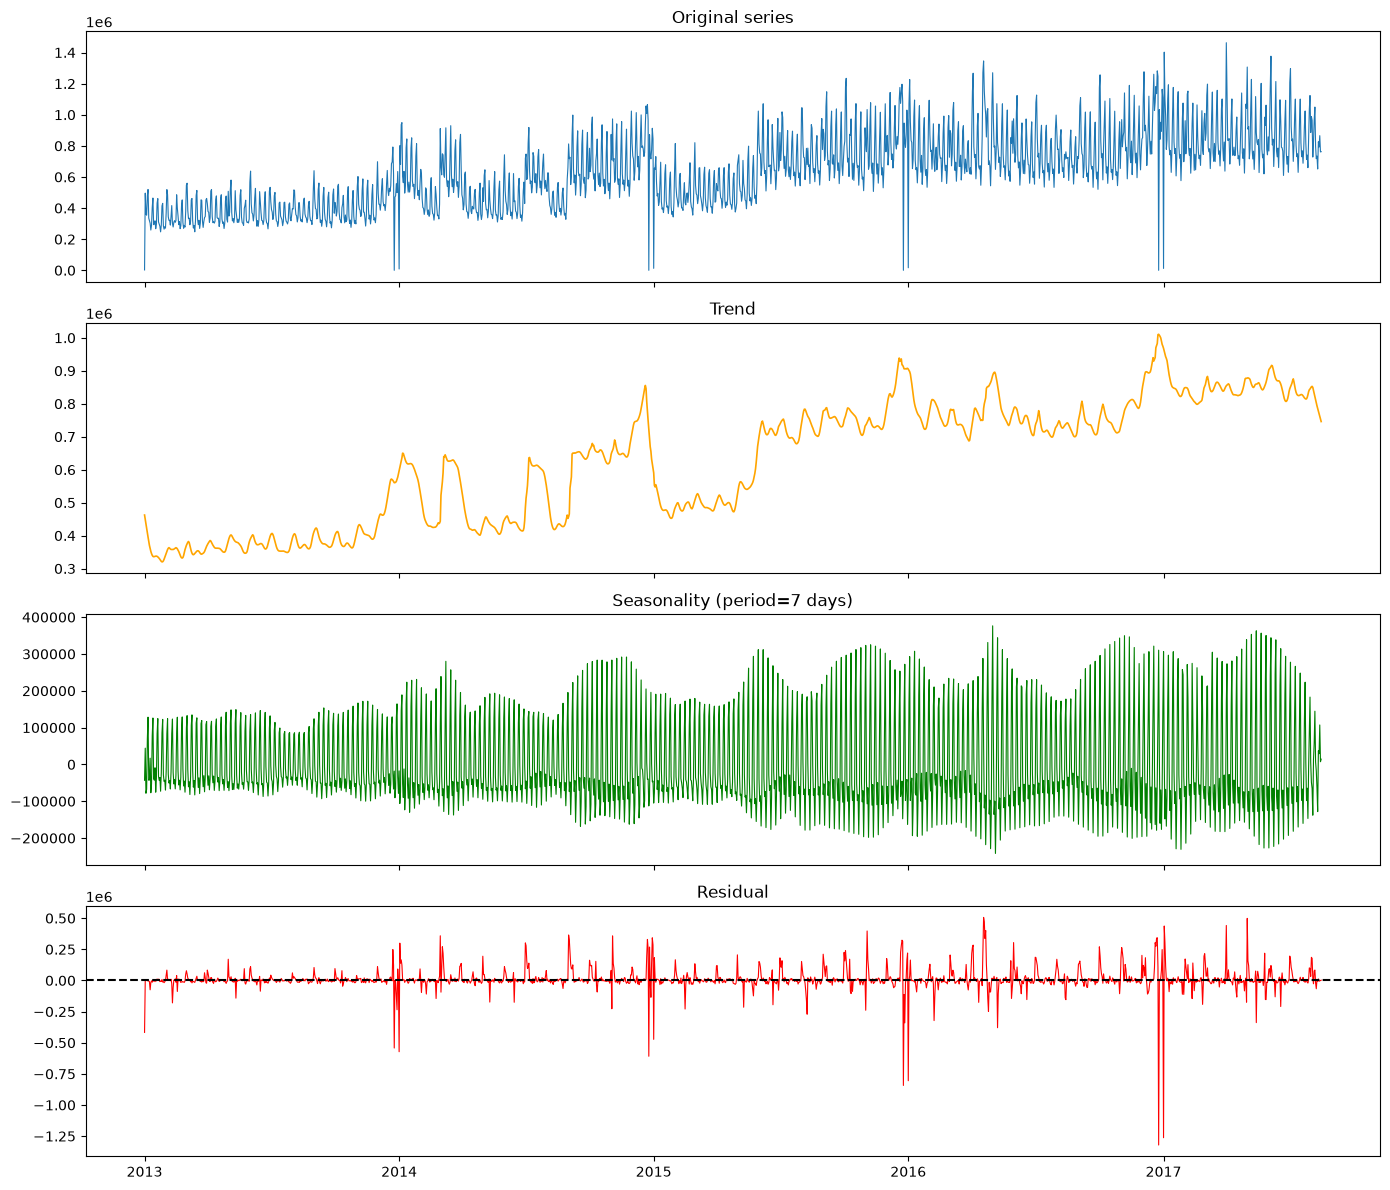

Trend strength:      0.793  (0 — none, 1 — very strong)
Seasonality strength:  0.570  (0 — none, 1 — very strong)


In [26]:
# Take total daily sales
daily_sales = train.groupby("date")["sales"].sum().sort_index()

# Perform STL decomposition with weekly period
stl = STL(daily_sales, period=7, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(result.observed, linewidth=0.8)
axes[0].set_title("Original series")

axes[1].plot(result.trend, color="orange", linewidth=1.2)
axes[1].set_title("Trend")

axes[2].plot(result.seasonal, color="green", linewidth=0.8)
axes[2].set_title("Seasonality (period=7 days)")

axes[3].plot(result.resid, color="red", linewidth=0.8)
axes[3].axhline(0, linestyle="--", color="black")
axes[3].set_title("Residual")

plt.tight_layout()
plt.show()

# Calculate trend and seasonality strength
var_resid = result.resid.var()
var_trend = (result.trend + result.resid).var()
var_seasonal = (result.seasonal + result.resid).var()

strength_trend = max(0, 1 - var_resid / var_trend)
strength_seasonal = max(0, 1 - var_resid / var_seasonal)

print(f"Trend strength:      {strength_trend:.3f}  (0 — none, 1 — very strong)")
print(f"Seasonality strength:  {strength_seasonal:.3f}  (0 — none, 1 — very strong)")

<Axes: xlabel='city'>

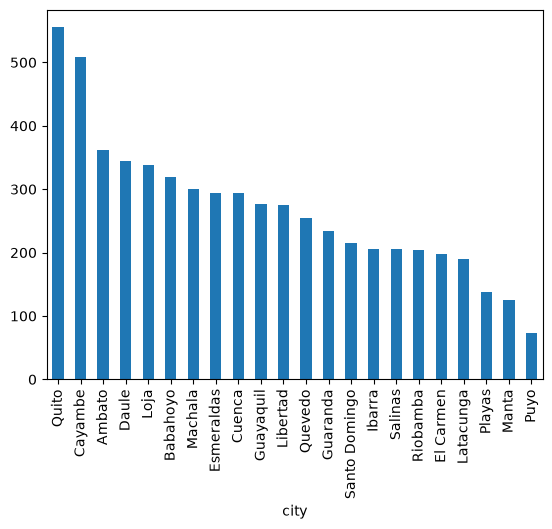

In [27]:
# Compare sales by city
# Use the stores table
train.merge(stores, on="store_nbr").groupby("city")["sales"].mean().sort_values(ascending=False).plot(kind="bar")

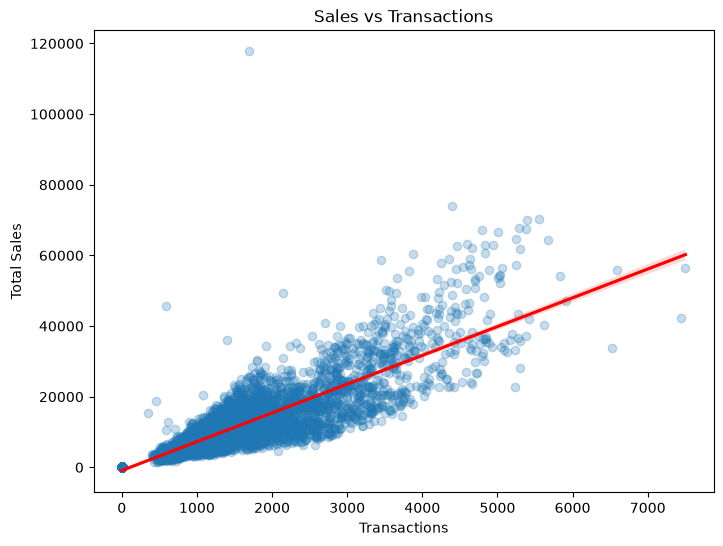

In [28]:
# Merge daily store sales with transactions
sales_transactions = (
    train.groupby(["date", "store_nbr"])["sales"]
    .sum()
    .reset_index()
    .merge(transactions, on=["date", "store_nbr"], how="inner")
)

# Build the sales vs transactions relationship on a sample
plt.figure(figsize=(8, 6))
sns.regplot(
    data=sales_transactions.sample(5000, random_state=42),
    x="transactions",
    y="sales",
    scatter_kws={"alpha": 0.25},
    line_kws={"color": "red"}
)
plt.title("Sales vs Transactions")
plt.xlabel("Transactions")
plt.ylabel("Total Sales")
plt.show()


In [29]:
# Analyze the impact of holidays on sales

# Prepare data for holiday analysis
def prepare_holiday_features(train, holidays, stores):

    # Exclude transferred holidays
    hol = holidays[holidays["transferred"] == False].copy()

    # Add city and state for each store
    train_h = train.merge(
        stores[["store_nbr", "city", "state"]],
        on="store_nbr",
        how="left"
    )

    # Merge with the holidays table
    train_h = train_h.merge(
        hol[["date", "locale", "locale_name", "description"]],
        on="date",
        how="left"
    )

    # Check whether the holiday applies to a specific store
    def is_real_holiday(row):
        if pd.isna(row["locale"]): return 0
        if row["locale"] == "National": return 1
        if row["locale"] == "Regional" and row["locale_name"] == row["state"]: return 1
        if row["locale"] == "Local" and row["locale_name"] == row["city"]: return 1
        return 0

    # Create a flag for relevant holiday
    train_h["is_holiday"] = train_h.apply(is_real_holiday, axis=1)

    # Calculate average sales as the baseline level
    baseline = (
        train.groupby(["store_nbr", "family"])["sales"]
        .mean()
        .rename("baseline")
        .reset_index()
    )

    # Add baseline to the data
    train_h = train_h.merge(baseline, on=["store_nbr", "family"], how="left")

    # Normalize sales relative to baseline
    train_h["sales_ratio"] = train_h["sales"] / (train_h["baseline"] + 1e-6)

    return train_h

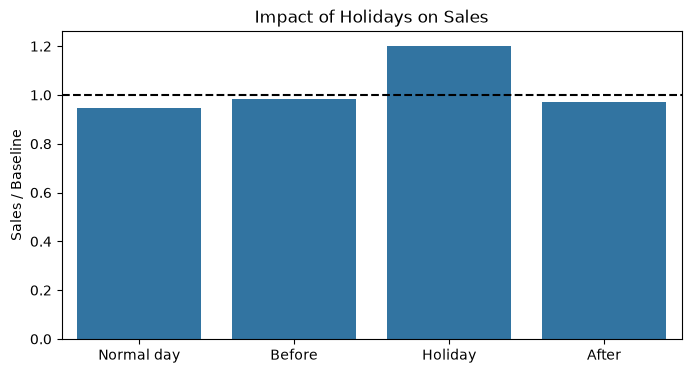

In [30]:

# Look at the effect on the holiday day, before, and after

train_h = prepare_holiday_features(train, holidays, stores)

# Take the dates of relevant holidays
holiday_dates = train_h.loc[train_h["is_holiday"] == 1, "date"].drop_duplicates()

# Create offset relative to the holiday
train_h["day_offset"] = None

# Holiday day
train_h.loc[train_h["is_holiday"] == 1, "day_offset"] = 0

# Day before holiday
train_h.loc[
    (train_h["is_holiday"] == 0) &
    (train_h["date"] + pd.Timedelta(days=1)).isin(holiday_dates),
    "day_offset"
] = -1

# Day after holiday
train_h.loc[
    (train_h["is_holiday"] == 0) &
    (train_h["date"] - pd.Timedelta(days=1)).isin(holiday_dates),
    "day_offset"
] = 1

# All other days are considered normal
train_h["day_offset"] = train_h["day_offset"].fillna(99).astype(int)

# Calculate the average effect
sales_window = (
    train_h
    .groupby("day_offset")["sales_ratio"]
    .mean()
    .reindex([99, -1, 0, 1])
    .reset_index()
)

# Add labels for the chart
sales_window["day_label"] = sales_window["day_offset"].map({
    99: "Normal day",
    -1: "Before",
     0: "Holiday",
     1: "After"
})

# Build the chart
plt.figure(figsize=(8, 4))

sns.barplot(
    data=sales_window,
    x="day_label",
    y="sales_ratio",
    order=["Normal day", "Before", "Holiday", "After"]
)

plt.axhline(1, linestyle="--", color="black")
plt.title("Impact of Holidays on Sales")
plt.ylabel("Sales / Baseline")
plt.xlabel("")

plt.show()

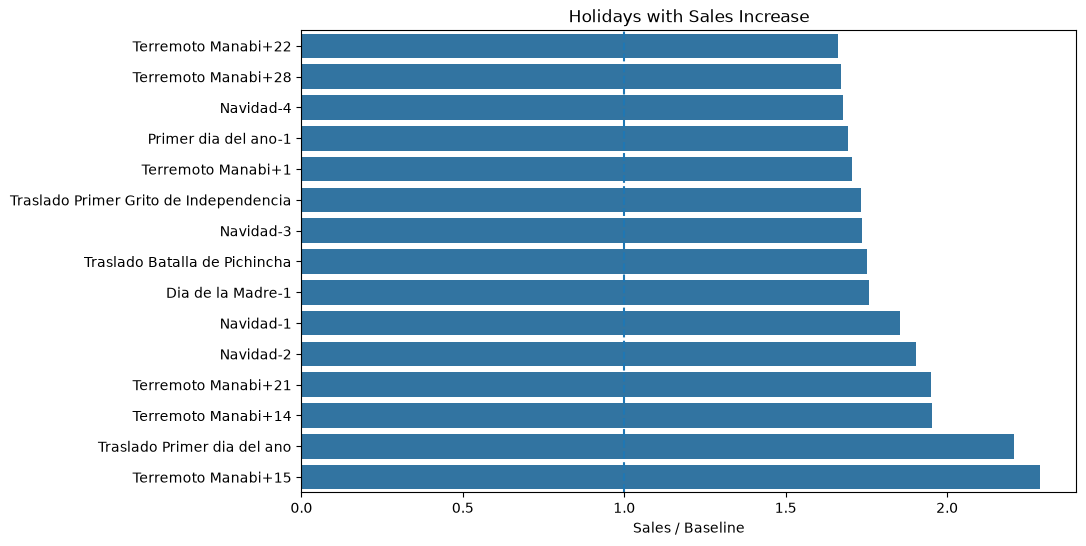

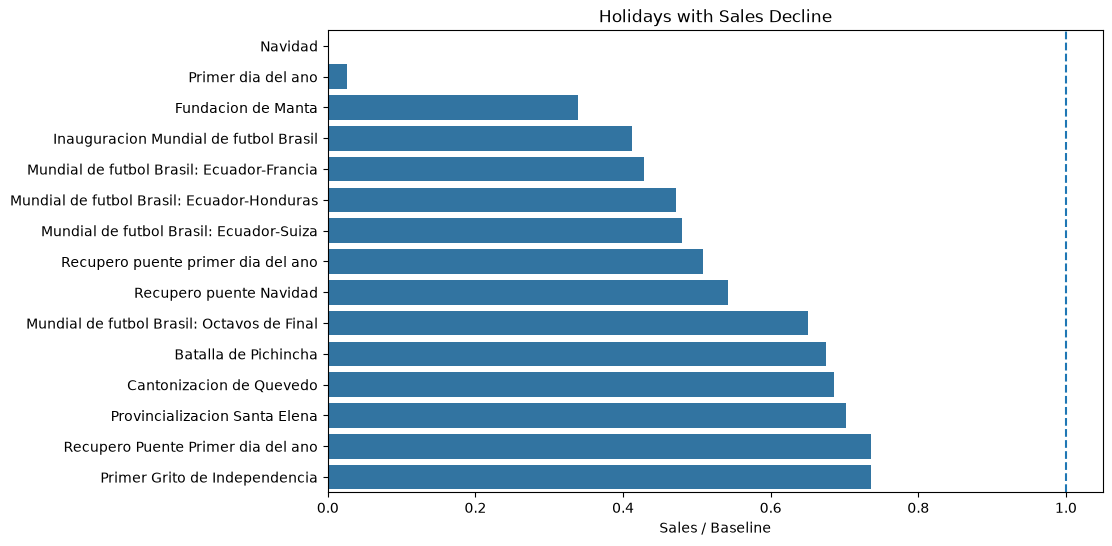

In [31]:
# Analyze the effect by holiday names

train_h = prepare_holiday_features(train, holidays, stores)

# Keep only relevant holidays
train_h = train_h[train_h["is_holiday"] == 1].copy()

# Calculate the average effect by holiday type
holiday_effect = (
    train_h
    .groupby("description")["sales_ratio"]
    .agg(["mean", "count"])
    .reset_index()
)

# Remove rare events
holiday_effect = holiday_effect[holiday_effect["count"] > 50]

# Sort by average effect
holiday_effect = holiday_effect.sort_values("mean")

# Top holidays with sales increase
plt.figure(figsize=(10, 6))
sns.barplot(data=holiday_effect.tail(15), x="mean", y="description")
plt.axvline(1, linestyle="--")
plt.title("Holidays with Sales Increase")
plt.xlabel("Sales / Baseline")
plt.ylabel("")
plt.show()

# Top holidays with sales decline
plt.figure(figsize=(10, 6))
sns.barplot(data=holiday_effect.head(15), x="mean", y="description")
plt.axvline(1, linestyle="--")
plt.title("Holidays with Sales Decline")
plt.xlabel("Sales / Baseline")
plt.ylabel("")
plt.show()

In [32]:
# Check unique holiday names
holidays["description"].unique()

<StringArray>
[                    'Fundacion de Manta',
          'Provincializacion de Cotopaxi',
                    'Fundacion de Cuenca',
              'Cantonizacion de Libertad',
              'Cantonizacion de Riobamba',
                 'Cantonizacion del Puyo',
              'Cantonizacion de Guaranda',
          'Provincializacion de Imbabura',
             'Cantonizacion de Latacunga',
                   'Fundacion de Machala',
 ...
                    'Terremoto Manabi+28',
                    'Terremoto Manabi+29',
                    'Terremoto Manabi+30',
          'Traslado Batalla de Pichincha',
        'Traslado Fundacion de Guayaquil',
 'Traslado Primer Grito de Independencia',
                 'Puente Dia de Difuntos',
        'Recupero Puente Dia de Difuntos',
            'Traslado Primer dia del ano',
            'Traslado Fundacion de Quito']
Length: 103, dtype: str

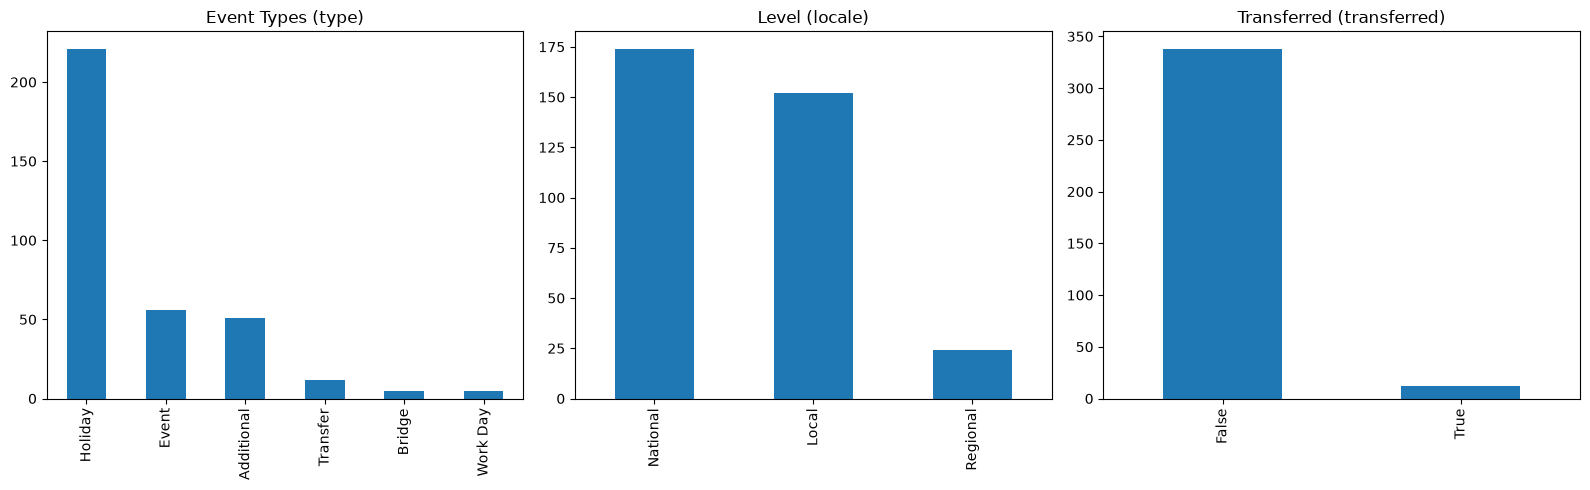

Distribution of events by category:
event_category
City / Province Foundation    158
New Year / Christmas           55
Independence Day / Battles     48
Manabi Earthquake              31
Other                          20
Football World Cup             14
Carnival                       10
Day of the Dead                 8
Black Friday                    3
Cyber Monday                    3


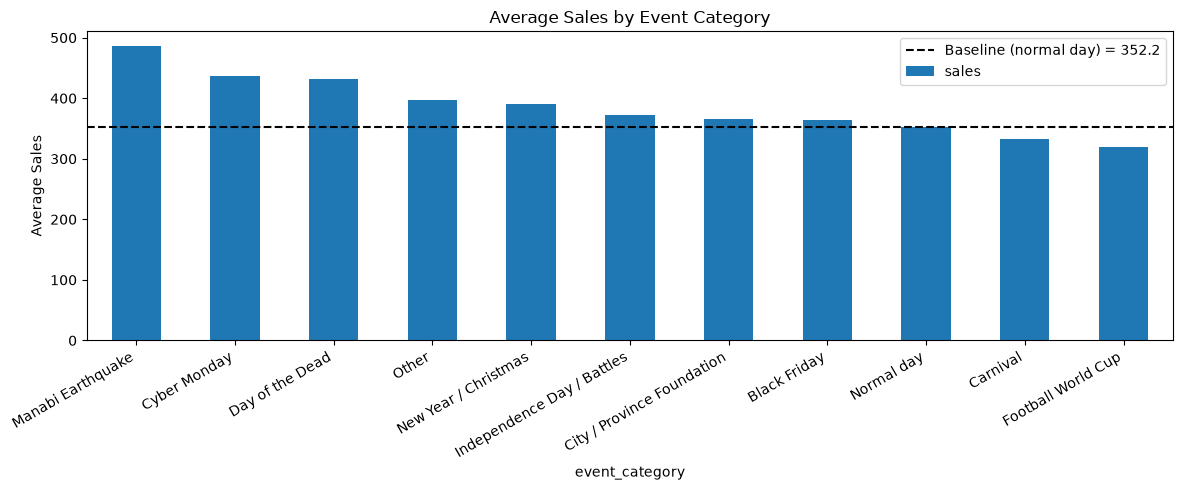

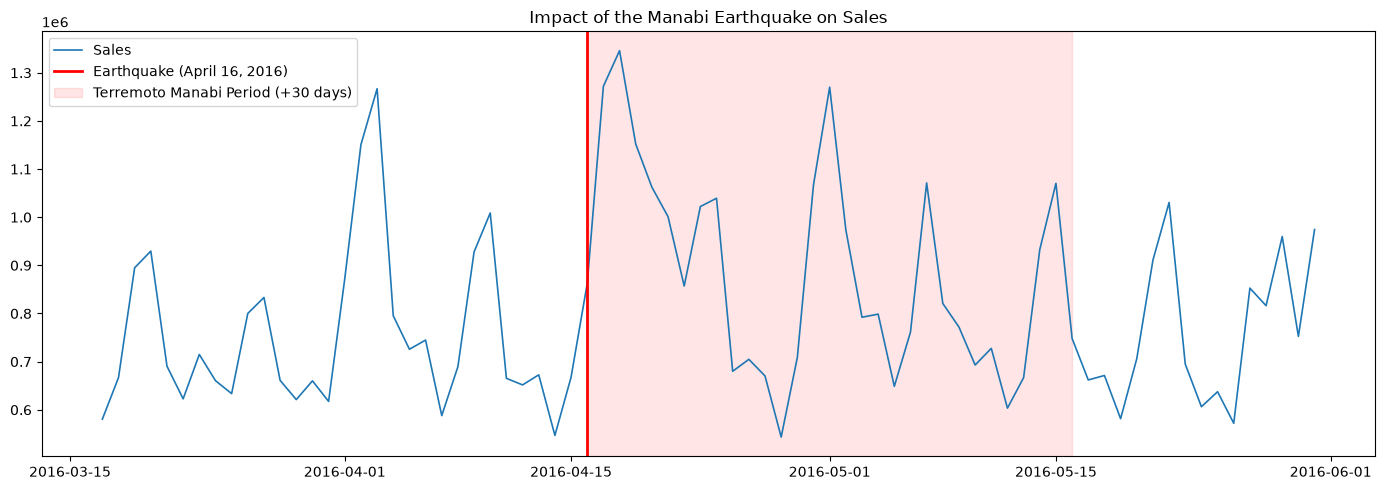

Average sales for 30 days BEFORE:   422.0
Average sales during +30 day period: 494.9  (+17.3%)
Average sales for 15 days AFTER:    427.6   (+1.3%)


In [33]:
# Analyze the composition of the holidays table

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Event type
holidays["type"].value_counts().plot(kind="bar", ax=axes[0], title="Event Types (type)")
axes[0].set_xlabel("")

# Event level
holidays["locale"].value_counts().plot(kind="bar", ax=axes[1], title="Level (locale)")
axes[1].set_xlabel("")

# Transferred holidays
holidays["transferred"].value_counts().plot(kind="bar", ax=axes[2], title="Transferred (transferred)")
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()

# Group events by meaning

# Manually classify events
def classify_event(desc):
    desc = str(desc).lower()
    if "terremoto" in desc:
        return "Manabi Earthquake"
    elif "black friday" in desc:
        return "Black Friday"
    elif "cyber monday" in desc:
        return "Cyber Monday"
    elif "mundial" in desc or "inauguracion mundial" in desc:
        return "Football World Cup"
    elif "navidad" in desc or "primer dia del ano" in desc:
        return "New Year / Christmas"
    elif "carnaval" in desc:
        return "Carnival"
    elif "difuntos" in desc:
        return "Day of the Dead"
    elif "independencia" in desc or "batalla" in desc or "grito" in desc:
        return "Independence Day / Battles"
    elif "fundacion" in desc or "cantonizacion" in desc or "provincializacion" in desc:
        return "City / Province Foundation"
    else:
        return "Other"

holidays["event_category"] = holidays["description"].apply(classify_event)

print("Distribution of events by category:")
print(holidays["event_category"].value_counts().to_string())

# Look at sales by event categories

train_cat = train.merge(
    holidays[["date", "event_category"]].drop_duplicates("date"),
    on="date",
    how="left"
)
train_cat["event_category"] = train_cat["event_category"].fillna("Normal day")

event_sales = (
    train_cat.groupby("event_category")["sales"]
    .mean()
    .sort_values(ascending=False)
)

baseline = train_cat[train_cat["event_category"] == "Normal day"]["sales"].mean()

plt.figure(figsize=(12, 5))
bars = event_sales.plot(kind="bar", title="Average Sales by Event Category")
plt.axhline(baseline, linestyle="--", color="black", label=f"Baseline (normal day) = {baseline:.1f}")
plt.legend()
plt.ylabel("Average Sales")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Separately inspect the Manabi earthquake effect

# Earthquake date
earthquake_date = pd.Timestamp("2016-04-16")

# Take a window of 30 days before and 45 days after
window_start = earthquake_date - pd.Timedelta(days=30)
window_end   = earthquake_date + pd.Timedelta(days=45)

daily_eq = (
    train[train["date"].between(window_start, window_end)]
    .groupby("date")["sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 5))
plt.plot(daily_eq["date"], daily_eq["sales"], linewidth=1.2, label="Sales")
plt.axvline(earthquake_date, color="red", linewidth=2, label="Earthquake (April 16, 2016)")
plt.axvspan(earthquake_date, earthquake_date + pd.Timedelta(days=30),
            alpha=0.1, color="red", label="Terremoto Manabi Period (+30 days)")
plt.title("Impact of the Manabi Earthquake on Sales")
plt.legend()
plt.tight_layout()
plt.show()

# Quantify the earthquake effect

before = train[train["date"].between(window_start, earthquake_date - pd.Timedelta(days=1))]["sales"].mean()
during = train[train["date"].between(earthquake_date, earthquake_date + pd.Timedelta(days=30))]["sales"].mean()
after  = train[train["date"].between(earthquake_date + pd.Timedelta(days=31), window_end)]["sales"].mean()

print(f"Average sales for 30 days BEFORE:   {before:,.1f}")
print(f"Average sales during +30 day period: {during:,.1f}  ({(during/before - 1)*100:+.1f}%)")
print(f"Average sales for 15 days AFTER:    {after:,.1f}   ({(after/before - 1)*100:+.1f}%)")

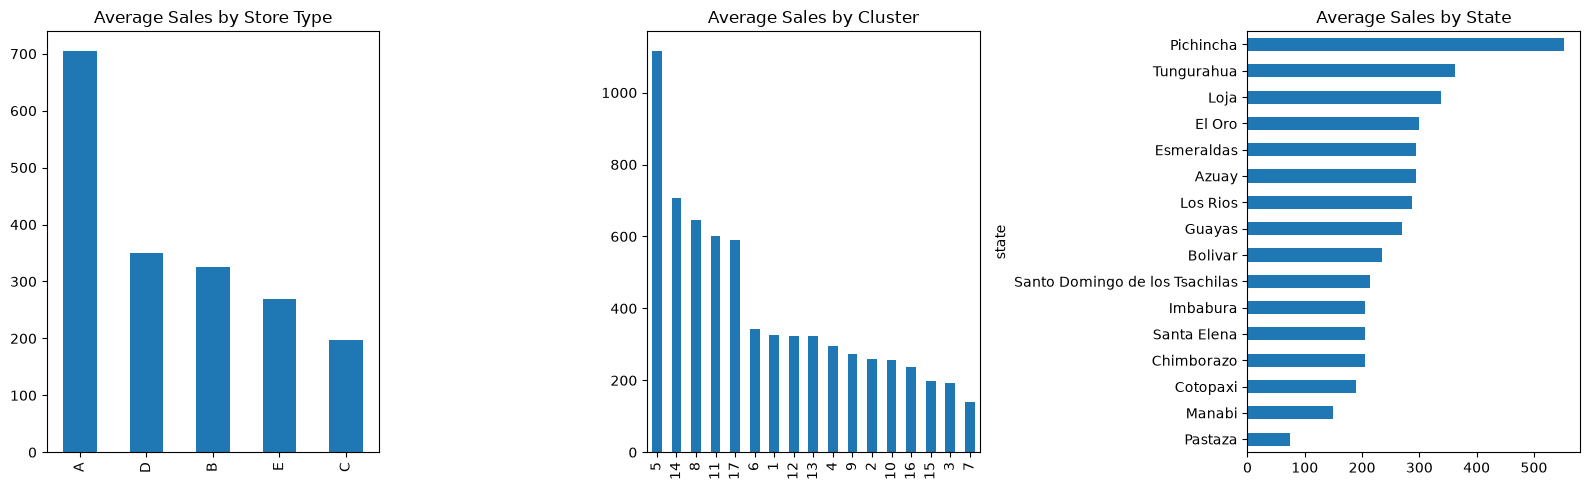

In [34]:
# Analyze stores: type, cluster, region

train_stores = train.merge(stores, on="store_nbr", how="left")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Average sales by store type
train_stores.groupby("type")["sales"].mean().sort_values(ascending=False).plot(
    kind="bar", ax=axes[0], title="Average Sales by Store Type"
)
axes[0].set_xlabel("")

# Average sales by cluster
train_stores.groupby("cluster")["sales"].mean().sort_values(ascending=False).plot(
    kind="bar", ax=axes[1], title="Average Sales by Cluster"
)
axes[1].set_xlabel("")

# Average sales by state
train_stores.groupby("state")["sales"].mean().sort_values().plot(
    kind="barh", ax=axes[2], title="Average Sales by State"
)
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()


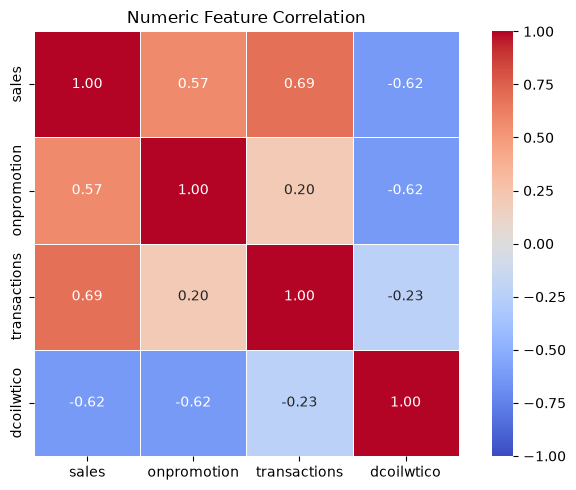

In [35]:
# Build a correlation matrix of numeric features

# Collect features at daily aggregation level
corr_df = (
    train.groupby("date")[["sales", "onpromotion"]]
    .mean()
    .merge(oil[["date", "dcoilwtico"]], on="date", how="left")
    .merge(
        transactions.groupby("date")["transactions"].mean().reset_index(),
        on="date", how="left"
    )
)

corr_matrix = corr_df[["sales", "onpromotion", "transactions", "dcoilwtico"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)
plt.title("Numeric Feature Correlation")
plt.tight_layout()
plt.show()


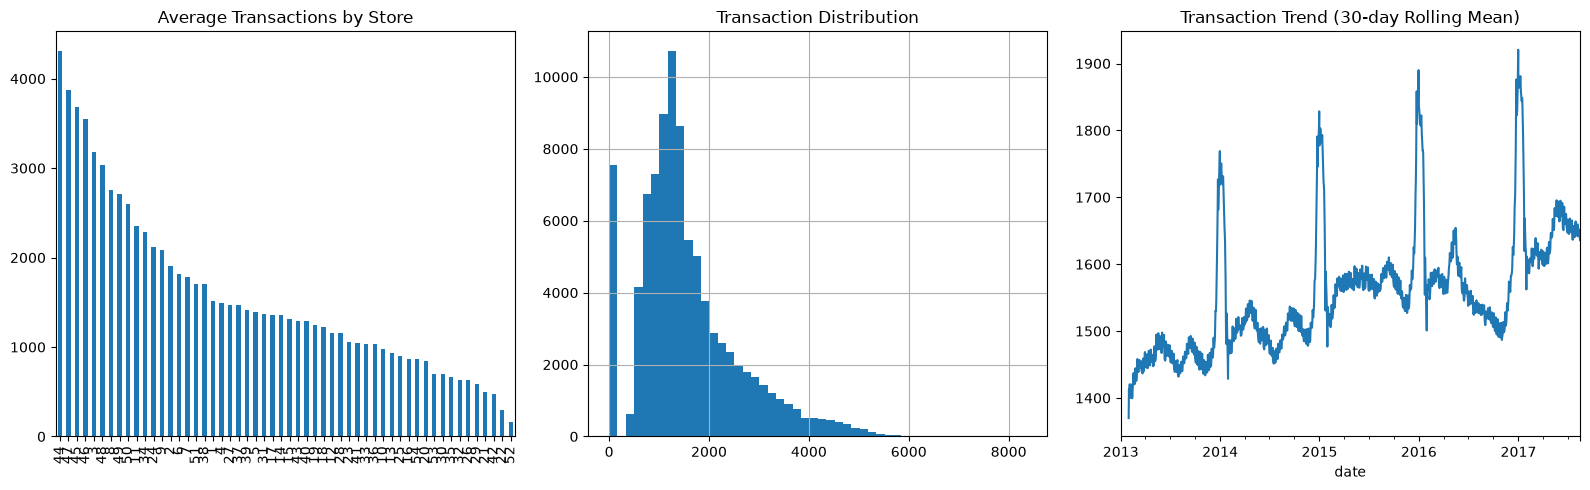

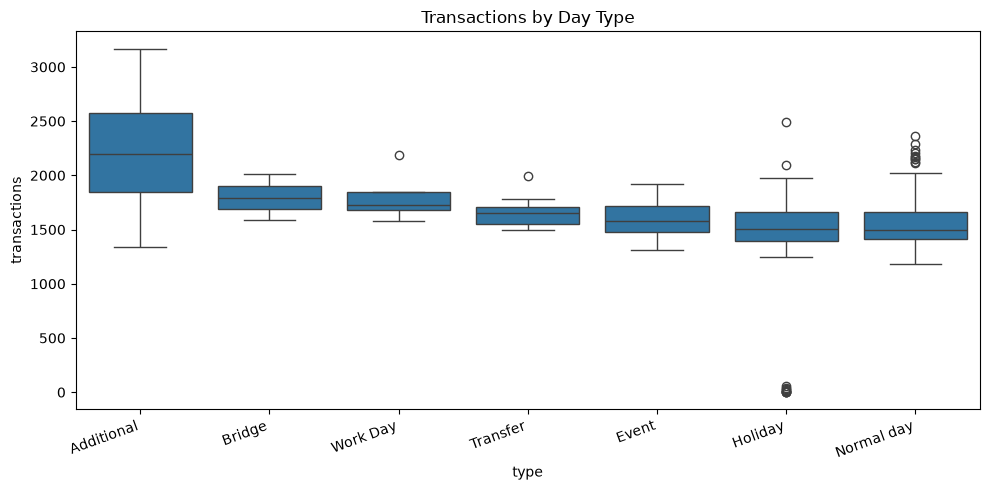

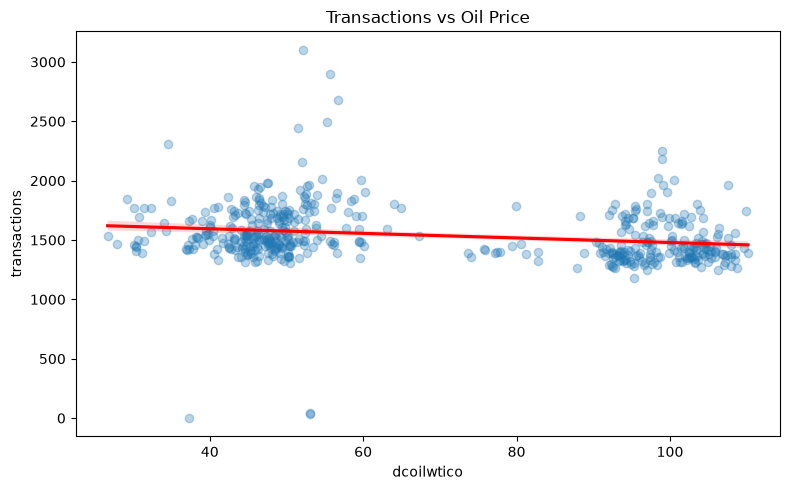

In [36]:
# Analyze transactions

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Average transactions by store
(
    transactions.groupby("store_nbr")["transactions"]
    .mean()
    .sort_values(ascending=False)
    .plot(kind="bar", ax=axes[0], title="Average Transactions by Store")
)
axes[0].set_xlabel("")

# Transaction count distribution
transactions["transactions"].hist(bins=50, ax=axes[1])
axes[1].set_title("Transaction Distribution")

# Transaction trend via 30-day rolling mean
(
    transactions.groupby("date")["transactions"]
    .mean()
    .rolling(30).mean()
    .plot(ax=axes[2], title="Transaction Trend (30-day Rolling Mean)")
)

plt.tight_layout()
plt.show()

# Compare transactions by day type

daily_trans = transactions.groupby("date")["transactions"].mean().reset_index()

daily_trans = daily_trans.merge(
    holidays[["date", "type"]].drop_duplicates("date"),
    on="date", how="left"
)
daily_trans["type"] = daily_trans["type"].fillna("Normal day")

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=daily_trans,
    x="type",
    y="transactions",
    order=daily_trans.groupby("type")["transactions"].median().sort_values(ascending=False).index
)
plt.title("Transactions by Day Type")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

# Compare transactions and oil price

trans_oil = daily_trans.merge(oil[["date", "dcoilwtico"]], on="date", how="left")

plt.figure(figsize=(8, 5))
sns.regplot(
    data=trans_oil.sample(500, random_state=42),
    x="dcoilwtico",
    y="transactions",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)
plt.title("Transactions vs Oil Price")
plt.tight_layout()
plt.show()

# 8 EDA Summary

The exploratory analysis revealed several important characteristics of the dataset.

### Key Findings

- Sales exhibit strong weekly and yearly seasonality.
- Promotions have a significant positive impact on sales.
- Product families differ considerably in their demand patterns.
- Oil prices and holidays may provide useful external signals.
- Transaction counts are positively correlated with sales.
- Different stores exhibit distinct sales behaviors.

These insights motivate the feature engineering techniques developed in the next notebook.